In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    pipeline, 
    Trainer, 
    TrainingArguments, 
    DataCollatorWithPadding
)

# Фиксируем seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Создаем папку для артефактов
os.makedirs("artifacts", exist_ok=True)

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
# Загружаем датасет emotion (6 классов: 0-sadness, 1-joy, 2-love, 3-anger, 4-fear, 5-surprise)
dataset = load_dataset("dair-ai/emotion", "split")
print(dataset)

df_train = dataset["train"].to_pandas()
display(df_train.head())

print("\nРаспределение классов в train:")
print(df_train['label'].value_counts())

# Комментарий: Датасет состоит из коротких англоязычных твитов. Классы не сбалансированы 
# (например, joy и sadness встречаются гораздо чаще, чем surprise).

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3



Распределение классов в train:
label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64


In [3]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = dataset["train"]["text"][:3]
print("Исходные тексты:\n", sample_texts)

# Демонстрация токенизации с padding и truncation
tokens = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")
print("\nInput IDs:\n", tokens["input_ids"])
print("\nAttention Mask:\n", tokens["attention_mask"])

print("\nДекодированный текст (с добавлением special tokens [CLS], [SEP], [PAD]):")
print(tokenizer.decode(tokens["input_ids"][0]))

Исходные тексты:
 ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong']

Input IDs:
 tensor([[  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0],
        [  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,  2061,
          9636, 17772,  2074,  2013,  2108,  2105,  2619,  2040, 14977,  1998,
          2003,  8300,   102],
        [  101, 10047,  9775,  1037,  3371,  2000,  2695,  1045,  2514, 20505,
          3308,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0]])

Attention Mask:
 tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 

In [4]:
# Используем готовую модель для бинарного анализа тональности (Sentiment Analysis), 
# чтобы показать её ограничения на 6-классовой задаче эмоций.
sentiment_pipe = pipeline(
    "text-classification", 
    model="distilbert-base-uncased-finetuned-sst-2-english", 
    device=0 if torch.cuda.is_available() else -1
)

test_samples = dataset["test"]["text"][:5]
print("Предсказания готовой (out-of-the-box) модели:")
for text in test_samples:
    pred = sentiment_pipe(text)
    print(f"Текст: '{text}'\nПредсказание: {pred}\n")

# Комментарий: Готовая модель классифицирует тексты только на POSITIVE и NEGATIVE. 
# Она не может отличить страх (fear) от злости (anger) или грусти (sadness). 
# Поэтому для нашей задачи требуется fine-tuning.

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 1765.92it/s]


Предсказания готовой (out-of-the-box) модели:
Текст: 'im feeling rather rotten so im not very ambitious right now'
Предсказание: [{'label': 'NEGATIVE', 'score': 0.9998108744621277}]

Текст: 'im updating my blog because i feel shitty'
Предсказание: [{'label': 'NEGATIVE', 'score': 0.9994602799415588}]

Текст: 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her'
Предсказание: [{'label': 'POSITIVE', 'score': 0.9993082284927368}]

Текст: 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived'
Предсказание: [{'label': 'POSITIVE', 'score': 0.9868245720863342}]

Текст: 'i was feeling a little vain when i did this one'
Предсказание: [{'label': 'NEGATIVE', 'score': 0.999649167060852}]



In [5]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {v: k for k, v in id2label.items()}

# Загружаем базовую модель с новой классификационной головой на 6 классов
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=6, id2label=id2label, label2id=label2id
).to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 14451.16it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="outputs/hw13_emotion",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",  # В новых версиях transformers используется eval_strategy вместо evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Начинаем обучение...")
trainer.train()

Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.597530,0.200881,0.927500,0.901732
2,0.163537,0.159021,0.937500,0.915053
3,0.113294,0.149736,0.935500,0.913324


Writing model shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.64it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1500, training_loss=0.29145361836751305, metrics={'train_runtime': 234.7295, 'train_samples_per_second': 204.491, 'train_steps_per_second': 6.39, 'total_flos': 647803507542912.0, 'train_loss': 0.29145361836751305, 'epoch': 3.0})


Метрики на test: {'eval_loss': 0.18245965242385864, 'eval_accuracy': 0.9235, 'eval_f1_macro': 0.8831006711519359, 'eval_runtime': 2.5839, 'eval_samples_per_second': 774.016, 'eval_steps_per_second': 24.382, 'epoch': 3.0}


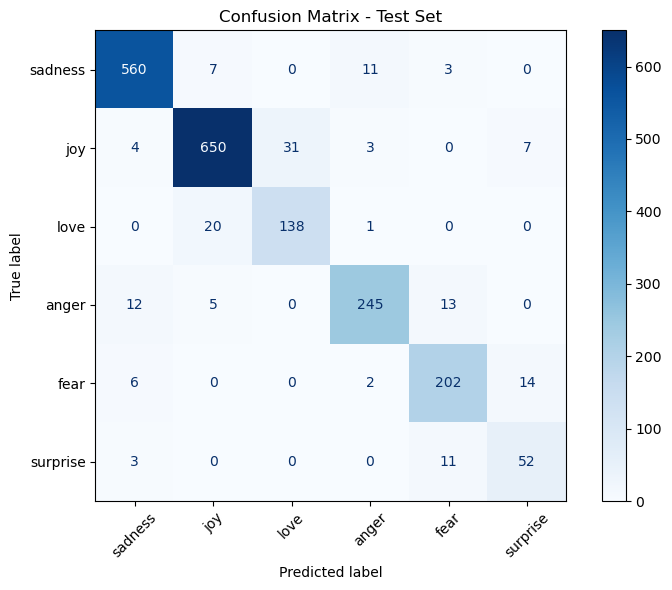

In [8]:
# Удаляем проблемный коллбэк перед standalone-оценкой
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка на тестовой выборке
test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("\nМетрики на test:", test_metrics)

test_preds_output = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(test_preds_output.predictions, axis=-1)
test_true = test_preds_output.label_ids

# Построение и сохранение матрицы ошибок
cm = confusion_matrix(test_true, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id2label.values()))
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

In [9]:
import torch.nn.functional as F

probs = F.softmax(torch.tensor(test_preds_output.predictions), dim=-1).numpy()
confidences = np.max(probs, axis=-1)

pred_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": [id2label[i] for i in test_true],
    "pred_label": [id2label[i] for i in test_preds],
    "confidence": confidences
})

# Сохраняем примеры предсказаний в artifacts
pred_df.sample(100, random_state=42).to_csv("artifacts/sample_predictions.csv", index=False)

# Анализ ошибок: выводим наиболее уверенные ошибки модели
errors = pred_df[pred_df["true_label"] != pred_df["pred_label"]]
confident_errors = errors.sort_values(by="confidence", ascending=False).head(10)

print("\nТоп уверенных ошибок модели:")
display(confident_errors)

# Комментарий к ошибкам:
# Модель часто путает 'joy' и 'love', так как они близки по эмоциональному окрасу.
# Также иногда 'sadness' путается с 'anger' в текстах, где присутствует сильное раздражение, 
# переходящее в отчаяние. Это связано с пересечением контекстов в коротких твитах.


Топ уверенных ошибок модели:


,text,true_label,pred_label,confidence
1270,i feel very saddened that the king whom i once...,joy,sadness,0.994252
1533,i actually was in a meeting last week where so...,anger,sadness,0.993743
816,whenever i put myself in others shoes and try ...,anger,joy,0.992695
1928,i feel inside cause life is like a game someti...,fear,sadness,0.989415
1377,i walked to school he felt the bounce in his s...,love,joy,0.988869
290,i just feel are ludicrous and wasting space or...,surprise,sadness,0.974418
1382,i cannot even begin to express in words the de...,surprise,sadness,0.973065
1608,i woke up and felt sad all over again but that...,joy,sadness,0.972545
1146,i feel affirmed gracious sensuous and will hav...,love,joy,0.970030
1613,i feel very cheated since i am supporting the ...,joy,sadness,0.964384
